# I.2 — The Logistic Map & the Edge of Chaos

One quadratic. That's the entire cast tonight:

$$x_{n+1} = r \, x_n (1 - x_n)$$

$x$ = this year's population (fraction of maximum), $r$ = growth rate.
The trick: feed each output back in as the next input — a function **composed with itself**,
exactly what you learned in Module 1. Then slowly turn the $r$ knob and watch mathematics lose its mind.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# The rule, as a Python function (a quadratic in disguise: rx - rx^2).
def step(x, r):
    return r * x * (1 - x)

# Iterate: output becomes the next input. This is f(f(f(...))) — composition with itself.
x = 0.2            # starting population: 20% of maximum
r = 2.5            # a calm growth rate
for year in range(20):
    x = step(x, r)
    print(f"year {year + 1:>2}: {x:.6f}")

year  1: 0.400000
year  2: 0.600000
year  3: 0.600000
year  4: 0.600000
year  5: 0.600000
year  6: 0.600000
year  7: 0.600000
year  8: 0.600000
year  9: 0.600000
year 10: 0.600000
year 11: 0.600000
year 12: 0.600000
year 13: 0.600000
year 14: 0.600000
year 15: 0.600000
year 16: 0.600000
year 17: 0.600000
year 18: 0.600000
year 19: 0.600000
year 20: 0.600000


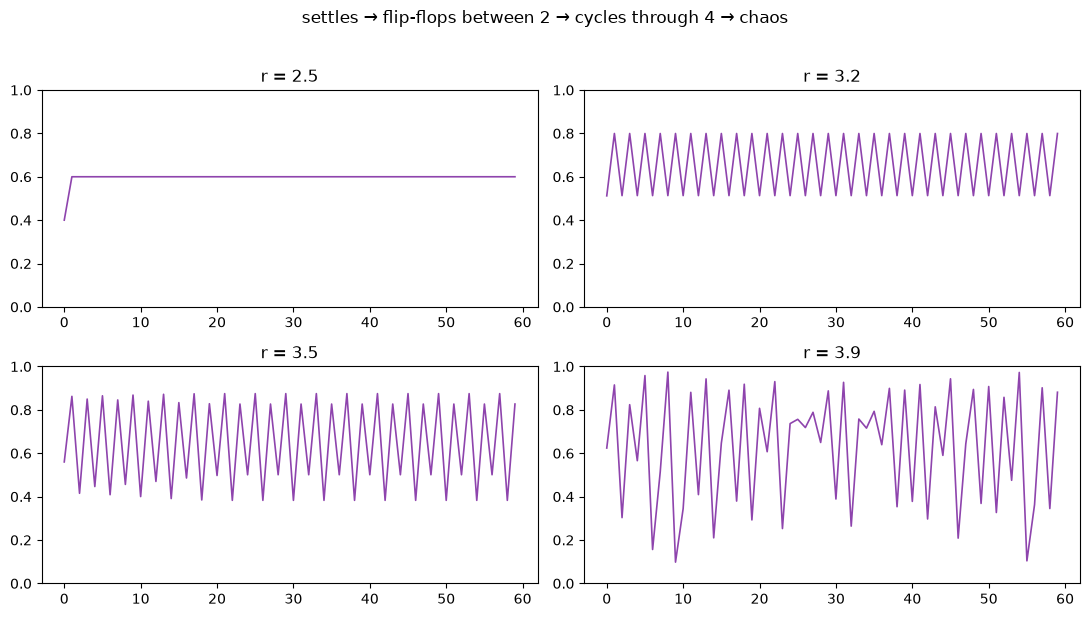

In [3]:
# Same rule, four settings of the knob. Watch the behaviour CHANGE SPECIES as r grows.
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, r in zip(axes.flat, [2.5, 3.2, 3.5, 3.9]):
    x, xs = 0.2, []
    for _ in range(60):
        x = step(x, r)
        xs.append(x)
    ax.plot(xs, linewidth=1.2, color="#8e44ad")
    ax.set_ylim(0, 1)
    ax.set_title(f"r = {r}")
fig.suptitle("settles → flip-flops between 2 → cycles through 4 → chaos", y=1.02)
plt.tight_layout()
plt.show()

## The bifurcation diagram

Now do that for *every* value of $r$ at once. For each growth rate: iterate 500 times to let the
population settle, then record the next 300 values — the places it *lives* long-term.
One dot per visited value. If it settles, you get one dot; if it flip-flops, two; if it's chaotic,
a smear. Plot all of it and you get one of the most famous images in mathematics.

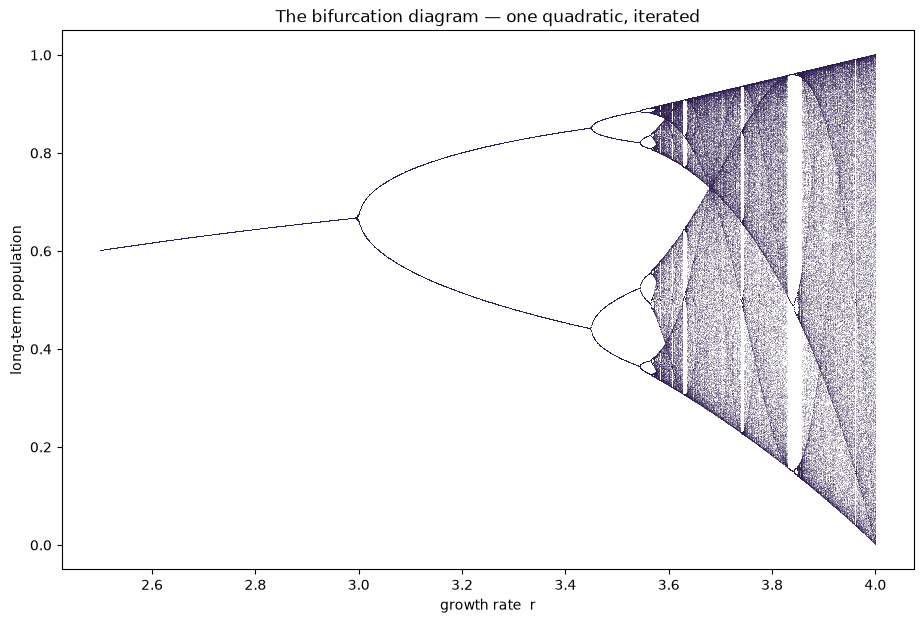

In [4]:
r = np.linspace(2.5, 4.0, 2000)       # 2000 growth rates, handled simultaneously
x = np.full_like(r, 0.2)              # 2000 populations, all starting at 0.2

for _ in range(500):                  # let every population settle in (nothing plotted yet)
    x = r * x * (1 - x)

plt.figure(figsize=(11, 7), facecolor="white")
for _ in range(300):                  # now record where each one lives
    x = r * x * (1 - x)
    plt.plot(r, x, ",", color="#2d1e50", alpha=0.25)   # "," = a single-pixel dot

plt.xlabel("growth rate  r")
plt.ylabel("long-term population")
plt.title("The bifurcation diagram — one quadratic, iterated")
plt.show()

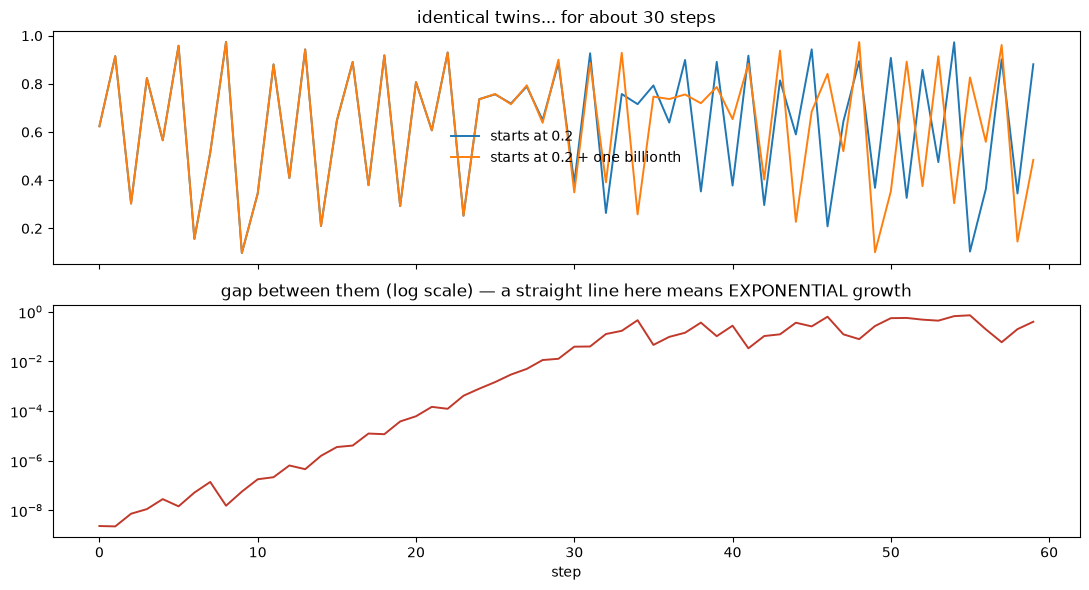

In [5]:
# The butterfly effect. Two populations at r = 3.9, differing by ONE BILLIONTH.
r = 3.9
a, b = 0.2, 0.2 + 1e-9               # 1e-9 is scientific notation: 0.000000001
history_a, history_b = [], []
for _ in range(60):
    a, b = step(a, r), step(b, r)
    history_a.append(a)
    history_b.append(b)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
top.plot(history_a, linewidth=1.4, label="starts at 0.2")
top.plot(history_b, linewidth=1.4, label="starts at 0.2 + one billionth")
top.legend(frameon=False)
top.set_title("identical twins... for about 30 steps")

diff = np.abs(np.array(history_a) - np.array(history_b))
bottom.semilogy(diff, color="#c0392b", linewidth=1.4)   # semilogy: log-scaled y-axis (Module 0.5!)
bottom.set_title("gap between them (log scale) — a straight line here means EXPONENTIAL growth")
bottom.set_xlabel("step")
plt.tight_layout()
plt.show()

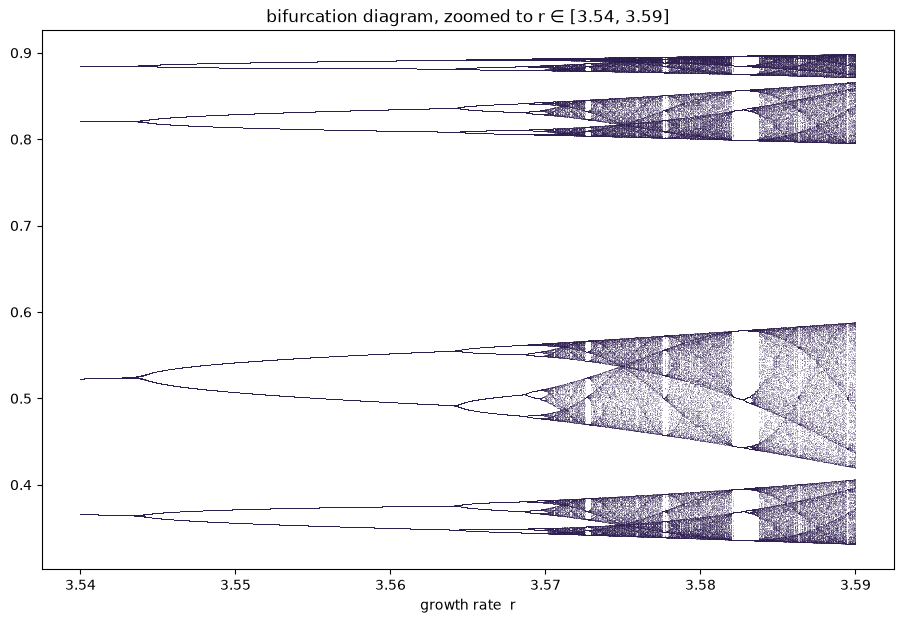

In [6]:
# YOUR TURN — zoom into the diagram. The structure repeats at every scale. Try:
#   r_min, r_max = 3.54, 3.59     (the doubling cascade, up close)
#   r_min, r_max = 3.84, 3.86     (an island of calm INSIDE the chaos — period 3)
r_min, r_max = 3.54, 3.59

r = np.linspace(r_min, r_max, 2000)
x = np.full_like(r, 0.2)
for _ in range(500):
    x = r * x * (1 - x)

plt.figure(figsize=(11, 7))
for _ in range(300):
    x = r * x * (1 - x)
    plt.plot(r, x, ",", color="#2d1e50", alpha=0.25)
plt.xlabel("growth rate  r")
plt.title(f"bifurcation diagram, zoomed to r ∈ [{r_min}, {r_max}]")
plt.show()

## What you just saw

A quadratic — the same species of function you sketched for the Module 1 boss — composed with
itself, produced: stability, rhythm, infinite branching, and behaviour so sensitive that a
billionth of a difference becomes everything. This is why weather forecasts die after ~10 days:
the atmosphere runs rules like this one, and no measurement is accurate to infinitely many decimals.

The branch splits arrive at a universal rhythm — each ~4.669× sooner than the last. That constant
(Feigenbaum's) appears in dripping taps, heart cells, boiling water: systems that share no physics,
only the *shape* of their math. Nobody invented it. It was found.

**The thread:** simple rules, iterated, create nature's complexity. Tonight you drilled function
iteration and composition without noticing — and "iterate a simple function many times" is
literally what a deep network's layers do.

*Done? Tell Claude what you found inside the period-3 window.*